In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score, confusion_matrix, roc_auc_score
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import GradientBoostingClassifier

RSEED = 50

In [3]:
df_ori = pd.read_csv('data/train.csv')
df = df_ori.copy().drop('id', axis=1)
df.head()

#print(df.isna().sum())

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [4]:
# map target 
target = "Irrigation_Need"

target_map = {"Low": 0, "Medium": 1, "High": 2}
df[target] = df[target].map(target_map)

In [5]:
# specify target and features

X = df.drop(columns=["Irrigation_Need"], axis=1)
y = df["Irrigation_Need"]

In [6]:
# train, eval split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=RSEED, stratify=y)
print(X_train.shape)
print(y_train.shape)
print('-----'*10)
print(X_val.shape)
print(y_val.shape)

(441000, 19)
(441000,)
--------------------------------------------------
(189000, 19)
(189000,)


In [7]:
binary_features = ["Mulching_Used"]

categorical_features = [
    "Soil_Type",
    "Crop_Type",
    "Irrigation_Type",
    "Water_Source",
    "Region",
    "Crop_Growth_Stage",
    "Season"
]

numeric_features = [col for col in X_train.columns if col not in categorical_features + binary_features]

print(1+len(binary_features) + len(numeric_features) + len(categorical_features))

20


In [8]:
# encoding categorical features

mulching_map = {"Yes": 1, "No": 0}
X_train["Mulching_Used"] = X_train["Mulching_Used"].map(mulching_map)
X_val["Mulching_Used"] = X_val["Mulching_Used"].map(mulching_map)

ohe = OneHotEncoder(drop="first", sparse=False, handle_unknown="ignore")
X_train_cat = ohe.fit_transform(X_train[categorical_features])
X_val_cat = ohe.transform(X_val[categorical_features])

cat_cols = ohe.get_feature_names_out(categorical_features)

# turn to df again
X_train_cat = pd.DataFrame(X_train_cat, columns=cat_cols, index=X_train.index)
X_val_cat = pd.DataFrame(X_val_cat, columns=cat_cols, index=X_val.index)

/Users/hedyeh/Ginger_Gradient/ds-ml-project/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [10]:
# scaling numerical features

scaler = MinMaxScaler()

X_train_num = scaler.fit_transform(X_train[numeric_features])
X_val_num = scaler.transform(X_val[numeric_features])

# save as df again
X_train_num = pd.DataFrame(X_train_num, columns=numeric_features, index=X_train.index)
X_val_num = pd.DataFrame(X_val_num, columns=numeric_features, index=X_val.index)

In [11]:
# create final train and validation sets 

X_train_final = pd.concat(
    [X_train_num, X_train_cat, X_train[binary_features]],
    axis=1
)

X_val_final = pd.concat(
    [X_val_num, X_val_cat, X_val[binary_features]],
    axis=1
)

print(X_train_final.shape)
print(X_val_final.shape)

(441000, 35)
(189000, 35)


# Done with the feature preprocessing

# Let's come up with a baseline model, first a heuristic model

In [12]:
# Heuristic baseline model

rf_low, rf_high = X_train_final["Rainfall_mm"].quantile([0.33, 0.66])
sm_low, sm_high = X_train_final["Soil_Moisture"].quantile([0.33, 0.66])
temp_low, temp_high = X_train_final["Temperature_C"].quantile([0.33, 0.66])
ws_low, ws_high = X_train_final["Wind_Speed_kmh"].quantile([0.33, 0.66])

def heuristic_model(row):
    
    Rainfall = row['Rainfall_mm']
    Soil_Moisture = row['Soil_Moisture']
    Temperature = row['Temperature_C']
    Wind_Speed = row['Wind_Speed_kmh']
    
    if (Soil_Moisture < sm_low) and (Temperature > temp_high) and (Rainfall < rf_low) and (Wind_Speed > ws_high):
        return 2  #high need for irrigation
    elif (sm_low <= Soil_Moisture <= sm_high) and (temp_low <= Temperature <= temp_high) and (rf_low <= Rainfall <= rf_high) and (ws_low <= Wind_Speed <= ws_high):
        return 1  # Medium need for irrig
    else:
        return 0  # Low need for irrig

# Apply baseline model to each row in the DataFrame
y_pred_heuristic = X_val_final.apply(heuristic_model, axis=1)

y_pred_prob_bl = np.zeros((len(y_pred_heuristic), 3))
for i, pred in enumerate(y_pred_heuristic):
    y_pred_prob_bl[i, pred] = 1

# accuracy according to pred from heuristic model 
print("Heuristic model accuracy:", accuracy_score(y_val, y_pred_heuristic))
print("Heuristic model F1 Score:", f1_score(y_val, y_pred_heuristic, average='macro'))

# accuracy according to prob from heuristic model
# convert prob to prediction and compare with real data    
y_pred_from_prob = np.argmax(y_pred_prob_bl, axis=1)
print('Accuracy of prob baseline model:', accuracy_score(y_val, y_pred_from_prob))


Heuristic model accuracy: 0.5870687830687831
Heuristic model F1 Score: 0.3479367904231146
Accuracy of prob baseline model: 0.5870687830687831


([<matplotlib.axis.XTick at 0x138fe1910>,
 [Text(0, 0, 'Low'), Text(1, 0, 'Medium'), Text(2, 0, 'High')])

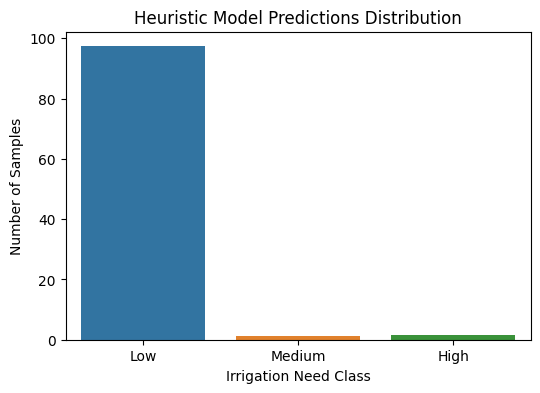

In [14]:
# plot the predicted classes for irrigation need
counts = y_pred_heuristic.value_counts().sort_index()
counts_percent = counts / counts.sum() * 100
# Plot
plt.figure(figsize=(6, 4))
sns.barplot(x=counts_percent.index, y=counts_percent.values)

plt.title("Heuristic Model Predictions Distribution")
plt.xlabel("Irrigation Need Class")
plt.ylabel("Number of Samples")

plt.xticks([0, 1, 2], ['Low', 'Medium', 'High'])

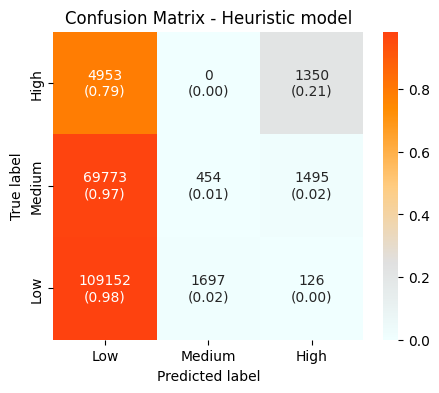

In [15]:
# Confusion Matrix for teh heuristic model
report_heu = classification_report(y_val, y_pred_heuristic, output_dict=True)
df_report_heu = pd.DataFrame(report_heu).transpose()

cm_heu = confusion_matrix(y_val, y_pred_heuristic)
cm_heu_norm = cm_heu.astype(float) / cm_heu.sum(axis=1, keepdims=True)

annot_heu = np.empty_like(cm_heu).astype(str)

for i in range(cm_heu.shape[0]):
    for j in range(cm_heu.shape[1]):
        annot_heu[i, j] = f"{cm_heu[i, j]}\n({cm_heu_norm[i, j]:.2f})"


from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list(
    "gray_to_orange",
    ["#F0FFFF", "#E0E0E0", "#FFCC80", "#FF8C00", "#FE420F"]
)

fig, ax = plt.subplots(1, 1, figsize=(5, 4))

sns.heatmap(cm_heu_norm, cmap=cmap, annot=annot_heu, fmt="", ax=ax, yticklabels=["Low", "Medium", "High"], xticklabels=["Low", "Medium", "High"])
ax.set_title("Confusion Matrix - Heuristic model")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.invert_yaxis()

### Great! 
### Now it is time to go for educated models: 
## Stochastic Gradient Descent model 
### and 
## Gradient Boosting model

In [16]:
sgd = SGDClassifier(loss="log_loss", class_weight="balanced", max_iter=1000, tol=1e-3, random_state=RSEED)
sgd

SGDClassifier(class_weight='balanced', loss='log_loss', random_state=50)

In [17]:
# SGD 
sgd.fit(X_train_final, y_train)
y_pred_sgd = sgd.predict(X_val_final)

y_pred_train_sgd = sgd.predict(X_train_final)

In [18]:
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RSEED)
gbc

GradientBoostingClassifier(random_state=50)

In [19]:
# GradientBoosting
gbc.fit(X_train_final, y_train)
y_pred_gbc = gbc.predict(X_val_final)

y_pred_train_gbc = gbc.predict(X_train_final)

In [20]:
y_prob_sgd = sgd.predict_proba(X_val_final)
y_prob_gbc = gbc.predict_proba(X_val_final)

y_prob_train_sgd = sgd.predict_proba(X_train_final)
y_prob_train_gbc = gbc.predict_proba(X_train_final)

In [21]:
print('------------ Validation Set ------------')
print('ACC SGD ', accuracy_score(y_val, y_pred_sgd))
print('F1 Score SGD', f1_score(y_val, y_pred_sgd, average='macro'))
print('Recall SGD', recall_score(y_val, y_pred_sgd, average='macro'))
print('ROC Score SGD', roc_auc_score(y_val, y_prob_sgd, multi_class='ovr'))

print('--------'*5)

print('ACC GBC', accuracy_score(y_val, y_pred_gbc))
print('F1 Score GBC', f1_score(y_val, y_pred_gbc, average='macro'))
print('Recall GBC', recall_score(y_val, y_pred_gbc, average='macro'))
print('ROC Score GBC', roc_auc_score(y_val, y_prob_gbc, multi_class='ovr'))


------------ Validation Set ------------
ACC SGD  0.8715185185185185
F1 Score SGD 0.7690227599275534
Recall SGD 0.7391609071207453
ROC Score SGD 0.9594541685027016
----------------------------------------
ACC GBC 0.9844550264550265
F1 Score GBC 0.9679196982301773
Recall GBC 0.9558240748206653
ROC Score GBC 0.9961133208589126


In [22]:
print('------------ Train Set ------------')
print('ACC SGD ', accuracy_score(y_train, y_pred_train_sgd))
print('F1 Score SGD', f1_score(y_train, y_pred_train_sgd, average='macro'))
print('Recall SGD', recall_score(y_train, y_pred_train_sgd, average='macro'))
print('ROC Score SGD', roc_auc_score(y_train, y_prob_train_sgd, multi_class='ovr'))

print('--------'*5)

print('ACC GBC', accuracy_score(y_train, y_pred_train_gbc))
print('F1 Score GBC', f1_score(y_train, y_pred_train_gbc, average='macro'))
print('Recall GBC', recall_score(y_train, y_pred_train_gbc, average='macro'))
print('ROC Score GBC', roc_auc_score(y_train, y_prob_train_gbc, multi_class='ovr'))


------------ Train Set ------------
ACC SGD  0.870938775510204
F1 Score SGD 0.7679919528935933
Recall SGD 0.7390119887461184
ROC Score SGD 0.9592379072675529
----------------------------------------
ACC GBC 0.9847777777777778
F1 Score GBC 0.9681012514571857
Recall GBC 0.956560834022642
ROC Score GBC 0.9961999760289939


### The two models seem not overfitting!

In [23]:
report_sgd = classification_report(y_val, y_pred_sgd, output_dict=True)
report_gbc = classification_report(y_val, y_pred_gbc, output_dict=True)

df_report_sgd = pd.DataFrame(report_sgd).transpose()
df_report_gbc = pd.DataFrame(report_gbc).transpose()

cm_sgd = confusion_matrix(y_val, y_pred_sgd)
cm_gbc = confusion_matrix(y_val, y_pred_gbc)

cm_sgd_norm = cm_sgd.astype(float) / cm_sgd.sum(axis=1, keepdims=True)
cm_gbc_norm = cm_gbc.astype(float) / cm_gbc.sum(axis=1, keepdims=True)


In [24]:
annot_sgd = np.empty_like(cm_sgd).astype(str)

for i in range(cm_sgd.shape[0]):
    for j in range(cm_sgd.shape[1]):
        annot_sgd[i, j] = f"{cm_sgd[i, j]}\n({cm_sgd_norm[i, j]:.2f})"


annot_gbc = np.empty_like(cm_gbc).astype(str)

for i in range(cm_gbc.shape[0]):
    for j in range(cm_gbc.shape[1]):
        annot_gbc[i, j] = f"{cm_gbc[i, j]}\n({cm_gbc_norm[i, j]:.2f})"

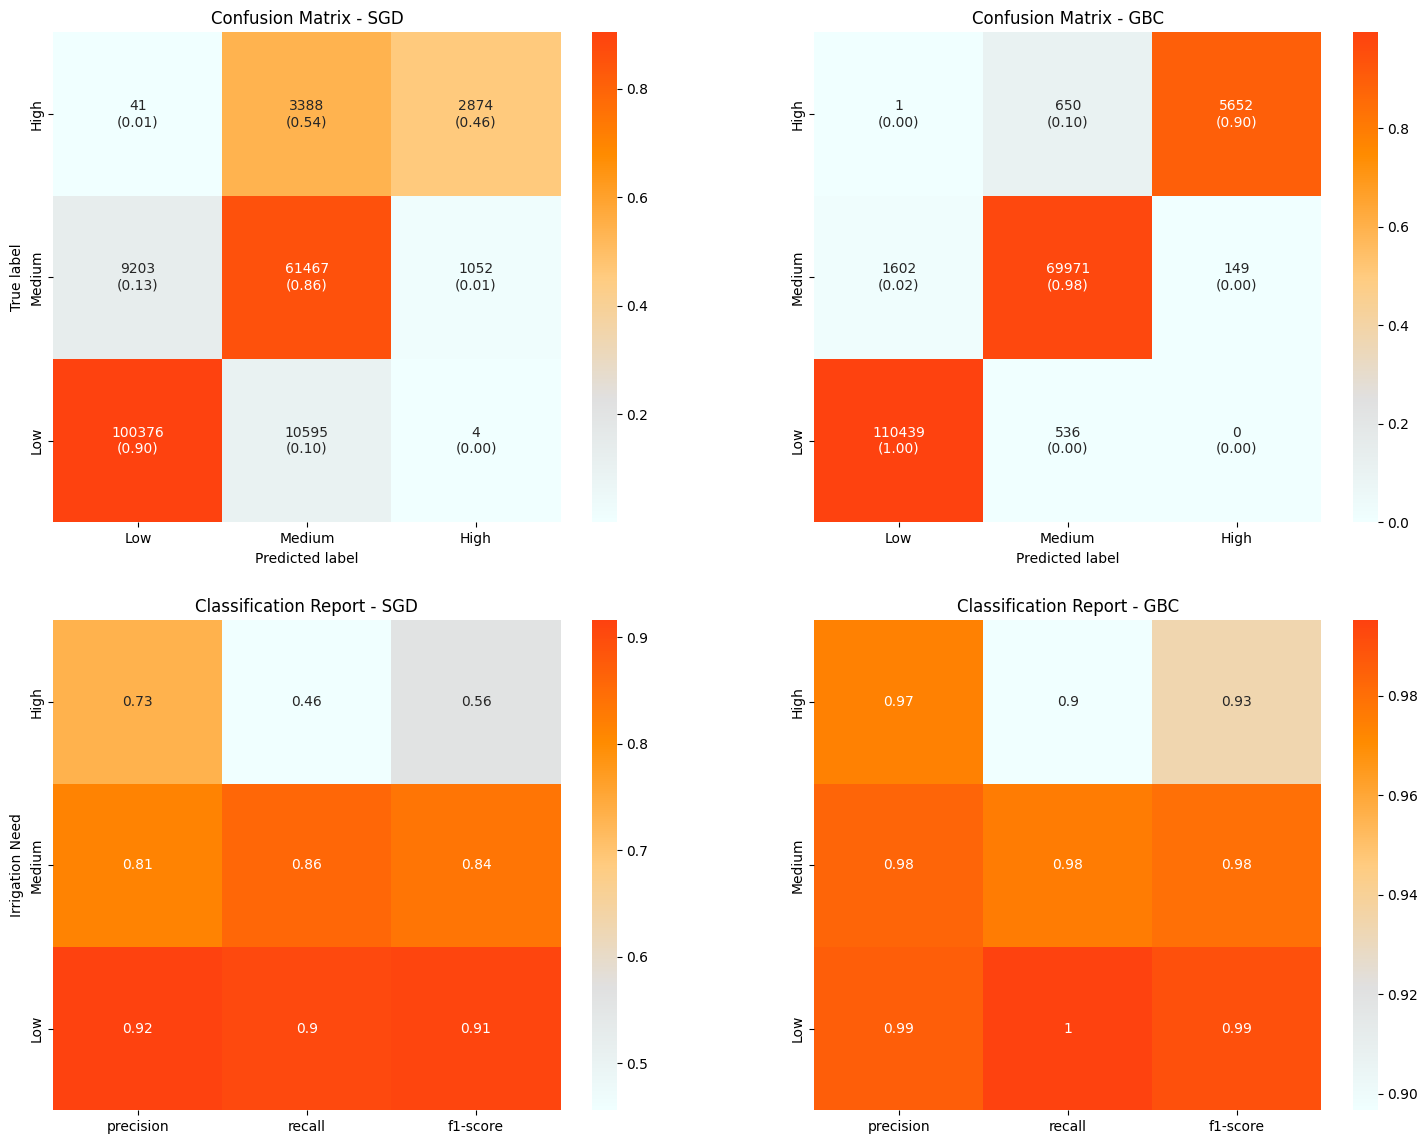

In [25]:
cmap = LinearSegmentedColormap.from_list(
    "gray_to_orange",
    ["#F0FFFF", "#E0E0E0", "#FFCC80", "#FF8C00", "#FE420F"]
)


fig, axes = plt.subplots(2, 2, figsize=(18, 14))

sns.heatmap(cm_sgd_norm, cmap=cmap, annot=annot_sgd, fmt="", ax=axes[0, 0], yticklabels=["Low", "Medium", "High"], xticklabels=["Low", "Medium", "High"])
axes[0, 0].set_title("Confusion Matrix - SGD")
axes[0, 0].set_xlabel("Predicted label")
axes[0, 0].set_ylabel("True label")
axes[0, 0].invert_yaxis()

sns.heatmap(cm_gbc_norm, cmap=cmap, annot=annot_gbc, fmt="", ax=axes[0, 1], yticklabels=["Low", "Medium", "High"], xticklabels=["Low", "Medium", "High"])
axes[0, 1].set_title("Confusion Matrix - GBC")
axes[0, 1].set_xlabel("Predicted label")
axes[0, 1].invert_yaxis()

sns.heatmap(df_report_sgd.iloc[:3, :3], cmap=cmap, annot=True, ax=axes[1, 0], yticklabels=["Low", "Medium", "High"])
axes[1, 0].set_title("Classification Report - SGD")
axes[1, 0].set_ylabel("Irrigation Need")
axes[1, 0].invert_yaxis()

sns.heatmap(df_report_gbc.iloc[:3, :3], cmap=cmap, annot=True, ax=axes[1, 1], yticklabels=["Low", "Medium", "High"])
axes[1, 1].set_title("Classification Report - GBC")
axes[1, 1].invert_yaxis()

# Hyperparameter tuning through GridSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
# SGDClassifier works fast, so I can do gridsearch for it. 
# took too long.
# I switch to RandomizedSearchCV

param_dist = {
    "loss": ["hinge", "log_loss", "modified_huber"],
    "max_iter": [1000, 2000, 5000],
    "penalty": ["l2", "l1", None],
    "alpha": [1e-4, 1e-3, 1e-2],
    "l1_ratio": [0.15, 0.5, 0.85],
    "learning_rate": ["optimal", "constant", "adaptive"],
    "eta0": [0.1, 1.0]
}

sgd = SGDClassifier(class_weight="balanced", tol=1e-3, random_state=RSEED)

rand_search = RandomizedSearchCV(
    estimator=sgd,
    param_distributions=param_dist,
    cv=5,
    n_jobs=-1,
    scoring="f1_macro",
    random_state=RSEED  
)

rand_search.fit(X_train_final, y_train)
best_model_sgd = rand_search.best_estimator_

print("Best SGD parameters:", rand_search.best_params_)
print("Best SGD CV score:", rand_search.best_score_)
print("Best SGD model:", best_model_sgd)

Best SGD parameters: {'penalty': None, 'max_iter': 2000, 'loss': 'log_loss', 'learning_rate': 'optimal', 'l1_ratio': 0.5, 'eta0': 0.1, 'alpha': 0.0001}
Best SGD CV score: 0.7829464591628529
Best SGD model: SGDClassifier(class_weight='balanced', eta0=0.1, l1_ratio=0.5, loss='log_loss',
              max_iter=2000, penalty=None, random_state=50)


In [106]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
# gbc does not support class_weight="balanced"
# so I use compute_sample_weight

gbc = GradientBoostingClassifier(random_state=RSEED)


sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

param_dist = {
    "n_estimators": [50, 100, 300],
    "learning_rate": [0.05, 0.2],
    "max_depth": [3, 5],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [2, 4],
    "subsample": [0.6, 1.0],
    "max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=gbc,
    param_distributions=param_dist,
    n_iter=30,        
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=RSEED
)

random_search.fit(X_train_final, y_train, sample_weight=sample_weights)
best_model_gbc = random_search.best_estimator_

print("Best GBC parameters:", random_search.best_params_)
print("Best GBC CV score:", random_search.best_score_)
print("Best GBC model:", best_model_gbc)

Best GBC parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5, 'learning_rate': 0.2}
Best GBC CV score: 0.9676780570060309
Best GBC model: GradientBoostingClassifier(learning_rate=0.2, max_depth=5, max_features='sqrt',
                           min_samples_leaf=4, min_samples_split=10,
                           n_estimators=300, random_state=50)


# Therefore, we have:
Best SGD model: SGDClassifier(class_weight='balanced', eta0=0.1, l1_ratio=0.5, loss='log_loss',
              max_iter=2000, penalty=None, random_state=50)


Best GBC model: GradientBoostingClassifier(learning_rate=0.2, max_depth=5, max_features='sqrt',
                           min_samples_leaf=4, min_samples_split=10,
                           n_estimators=300, random_state=50)

In [33]:
best_sgd = SGDClassifier(class_weight='balanced', eta0=0.1, l1_ratio=0.5, loss='log_loss', max_iter=2000, penalty=None, random_state=RSEED)
    
best_sgd.fit(X_train_final, y_train)
y_pred_best_sgd = best_sgd.predict(X_val_final)
y_pred_train_best_sgd = best_sgd.predict(X_train_final)

print('F1 Score Best SGD', f1_score(y_val, y_pred_best_sgd, average='macro'))
print('F1 Score Train Best SGD', f1_score(y_train, y_pred_train_best_sgd, average='macro'))

report_best_sgd = classification_report(y_val, y_pred_best_sgd, output_dict=True)
df_report_best_sgd = pd.DataFrame(report_best_sgd).transpose()

cm_best_sgd = confusion_matrix(y_val, y_pred_best_sgd)
cm_best_sgd_norm = cm_best_sgd.astype(float) / cm_best_sgd.sum(axis=1, keepdims=True)

annot_best_sgd = np.empty_like(cm_best_sgd).astype(str)

for i in range(cm_best_sgd.shape[0]):
    for j in range(cm_best_sgd.shape[1]):
        annot_best_sgd[i, j] = f"{cm_best_sgd[i, j]}\n({cm_best_sgd_norm[i, j]:.2f})"


F1 Score Best SGD 0.7812546835825279
F1 Score Train Best SGD 0.7795892605241627


In [32]:
best_sgd

SGDClassifier(class_weight='balanced', eta0=0.1, l1_ratio=0.5, loss='log_loss',
              max_iter=2000, penalty=None, random_state=50)

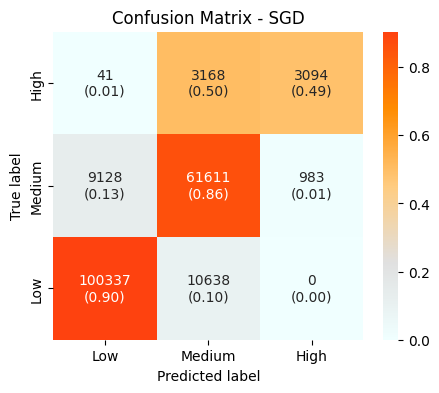

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

sns.heatmap(cm_best_sgd_norm, cmap=cmap, annot=annot_best_sgd, fmt="", ax=ax, yticklabels=["Low", "Medium", "High"], xticklabels=["Low", "Medium", "High"])
ax.set_title("Confusion Matrix - SGD")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.invert_yaxis()

In [34]:
best_gbc = GradientBoostingClassifier(learning_rate=0.2, max_depth=5, max_features='sqrt', min_samples_leaf=4, min_samples_split=10, n_estimators=300, random_state=RSEED)
best_gbc.fit(X_train_final, y_train)
y_pred_best_gbc = best_gbc.predict(X_val_final)
y_pred_train_best_gbc = best_gbc.predict(X_train_final)

print('F1 Score Best GBC', f1_score(y_val, y_pred_best_gbc, average='macro'))
print('F1 Score Train Best GBC', f1_score(y_train, y_pred_train_best_gbc, average='macro'))

report_best_gbc = classification_report(y_val, y_pred_best_gbc, output_dict=True)
df_report_best_gbc = pd.DataFrame(report_best_gbc).transpose()

cm_best_gbc = confusion_matrix(y_val, y_pred_best_gbc)
cm_best_gbc_norm = cm_best_gbc.astype(float) / cm_best_gbc.sum(axis=1, keepdims=True)

annot_best_gbc = np.empty_like(cm_best_gbc).astype(str)

for i in range(cm_best_gbc.shape[0]):
    for j in range(cm_best_gbc.shape[1]):
        annot_best_gbc[i, j] = f"{cm_best_gbc[i, j]}\n({cm_best_gbc_norm[i, j]:.2f})"


F1 Score Best GBC 0.9710038573215867
F1 Score Train Best GBC 0.9806437855130814


In [31]:
best_gbc

GradientBoostingClassifier(learning_rate=0.2, max_depth=5, max_features='sqrt',
                           min_samples_leaf=4, min_samples_split=10,
                           n_estimators=300, random_state=50)

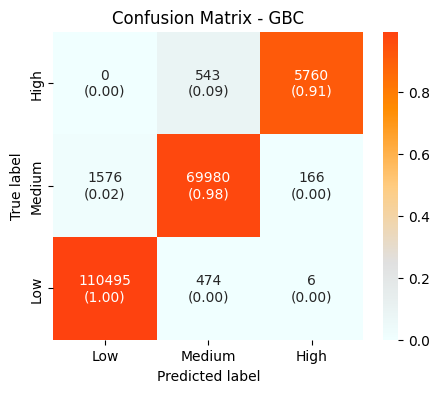

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

sns.heatmap(cm_best_gbc_norm, cmap=cmap, annot=annot_best_gbc, fmt="", ax=ax, yticklabels=["Low", "Medium", "High"], xticklabels=["Low", "Medium", "High"])
ax.set_title("Confusion Matrix - GBC")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.invert_yaxis()